# Nashville Housing Data EDA (Pre Analysis)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from scipy import stats

In [2]:
BLUE   = "#2563EB"
CORAL  = "#DC2626"
GREEN  = "#16A34A"
AMBER  = "#D97706"
PURPLE = "#7C3AED"
TEAL   = "#0891B2"
GRAY   = "#374151"
LIGHT  = "#F1F5F9"
 
CITY_PAL  = [BLUE, CORAL, GREEN, AMBER, PURPLE, TEAL, "#EC4899", "#F97316"]
TIER_PAL  = [GREEN, BLUE, AMBER, CORAL]         
LU_PAL    = [CORAL, BLUE, GREEN, AMBER, PURPLE]
YEAR_PAL  = [TEAL, BLUE, GREEN, AMBER, CORAL]

In [3]:
_style = ("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid"
          in plt.style.available else "seaborn-whitegrid")
plt.style.use(_style)
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlepad": 14, "font.family": "DejaVu Sans",
})

In [4]:
data = pd.read_excel(r"C:\Users\hp\Desktop\Shreya\Datasets\Nashville Housing Cleaned Data.xlsx")

In [5]:
data.shape

(56372, 23)

In [6]:
print("\n" + "=" * 65)
print("NULL & MISSING VALUE CHECK")
print("=" * 65)


null_counts   = data.isnull().sum()
null_percent  = (null_counts / len(data) * 100).round(2)
null_summary  = pd.DataFrame({
    'Missing Count'   : null_counts,
    'Missing %'       : null_percent,
    'Data Type'       : data.dtypes,
    'Non-Null Count'  : data.notnull().sum()
})
 
print("\n Missing value report:")
print(null_summary.to_string())
 
total_missing = null_counts.sum()
if total_missing == 0:
    print("\n No missing values found. Dataset is complete.")
else:
    print(f"\n Total missing cells: {total_missing}")
    print("   Columns with missing values:")
    print(null_counts[null_counts > 0])


NULL & MISSING VALUE CHECK

 Missing value report:
                         Missing Count  Missing %       Data Type  Non-Null Count
Row no.                              0        0.0           int64           56372
UniqueID                             0        0.0           int64           56372
ParcelID                             0        0.0          object           56372
Land Use                             0        0.0          object           56372
Sale Price                           0        0.0           int64           56372
Legal Reference                      0        0.0          object           56372
Sold As Vacant                       0        0.0          object           56372
Owner Name                           0        0.0          object           56372
Acreage                              0        0.0         float64           56372
TaxDistrict                          0        0.0          object           56372
Land Value                           0        

In [7]:
data["Sale Date"]    = pd.to_datetime(data["Sale Date"])
data["Sale_Year"]    = data["Sale Date"].dt.year
data["Sale_Quarter"] = data["Sale Date"].dt.quarter
data["Sale_Month"]   = data["Sale Date"].dt.month

In [8]:
# Drop the 2 stray 2019 rows
df = data[data["Sale_Year"] <= 2016].copy()
YEARS = sorted(data["Sale_Year"].unique()) 

In [9]:
display(df["Land Use"].value_counts())

SINGLE FAMILY                                 34117
RESIDENTIAL CONDO                             14064
VACANT RESIDENTIAL LAND                        5092
DUPLEX                                         1372
ZERO LOT LINE                                  1047
CONDO                                           247
RESIDENTIAL COMBO/MISC                           95
TRIPLEX                                          92
QUADPLEX                                         39
CONDOMINIUM OFC OR OTHER COM CONDO               35
CHURCH                                           33
MOBILE HOME                                      20
DORMITORY/BOARDING HOUSE                         19
VACANT COMMERCIAL LAND                           17
SPLIT CLASS                                      16
PARKING LOT                                      11
FOREST                                           10
GREENBELT                                        10
PARSONAGE                                         6
GREENBELT/RE

In [24]:
# Land use grouping

land_use_map = {
    "SINGLE FAMILY"                              : "Single Family",
    "ZERO LOT LINE"                              : "Single Family",
    "MOBILE HOME"                                : "Single Family",
    "PARSONAGE"                                  : "Single Family",
    "RESIDENTIAL CONDO"                          : "Condo",
    "CONDO"                                      : "Condo",
    "CONDOMINIUM OFC OR OTHER COM CONDO"         : "Condo",
    "DUPLEX"                                     : "Multi-Family",
    "TRIPLEX"                                    : "Multi-Family",
    "QUADPLEX"                                   : "Multi-Family",
    "RESIDENTIAL COMBO/MISC"                     : "Multi-Family",
    "SPLIT CLASS"                                : "Multi-Family",
    "APARTMENT: LOW RISE (BUILT SINCE 1960)"     : "Multi-Family",
    "DORMITORY/BOARDING HOUSE"                   : "Multi-Family",
    "VACANT RESIDENTIAL LAND"                    : "Vacant",
    "VACANT COMMERCIAL LAND"                     : "Vacant",
    "VACANT RURAL LAND"                          : "Vacant",
    "VACANT ZONED MULTI FAMILY"                  : "Vacant",
    "GREENBELT"                                  : "Vacant",
    "GREENBELT/RES GRRENBELT/RES"                : "Vacant",
    "FOREST"                                     : "Vacant",
    "PARKING LOT"                                : "Vacant",
}

In [25]:
df["Land_Use_Group"] = df["Land Use"].map(land_use_map).fillna("Commercial/Inst.")

LU_ORDER = ["Single Family", "Condo", "Multi-Family", "Vacant", "Commercial/Inst."]

In [26]:
print(df["Land_Use_Group"].value_counts())

Single Family       35190
Condo               14346
Vacant               5147
Multi-Family         1635
Commercial/Inst.       52
Name: Land_Use_Group, dtype: int64


In [27]:
# Price tier quartile based
TIER_ORDER = ["Budget", "Mid-Range", "Upper-Mid", "Luxury"]

df["Price_Category"] = pd.Categorical(
    pd.qcut(df["Sale Price"], q=4, labels=TIER_ORDER),
    categories=TIER_ORDER, ordered=True
)

print(df["Price_Category"].value_counts())

Budget       14210
Upper-Mid    14122
Luxury       14063
Mid-Range    13975
Name: Price_Category, dtype: int64


#### Top 8 Property Cities

In [28]:
top5_cities = df["Property City"].value_counts().head(5).index.tolist()

top8_cities = df["Property City"].value_counts().head(8).index.tolist()

(0.0, 376.072875)

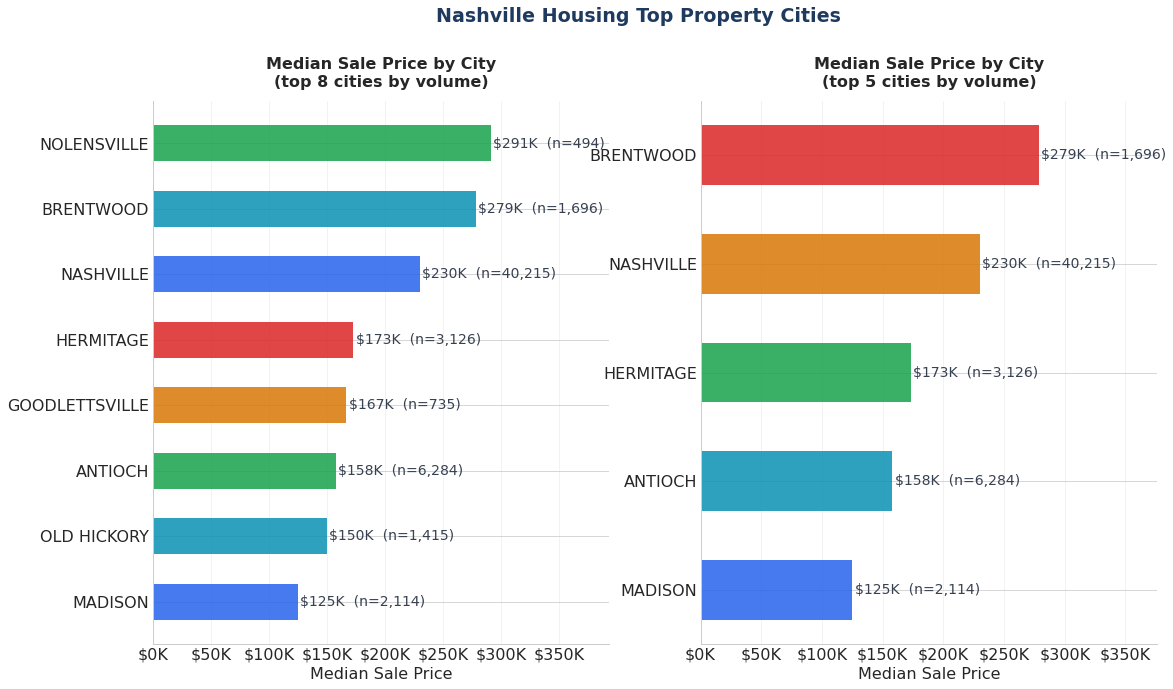

In [29]:
fig1, axes = plt.subplots(1, 2, figsize=(18, 10))
fig1.suptitle("Nashville Housing Top Property Cities",
              fontsize=19, fontweight="bold", color="#1E3A5F", y=1.01)
 
# Panel 1: Median price by city
ax = axes[0]
city_stats = (df[df["Property City"].isin(top8_cities)]
              .groupby("Property City")["Sale Price"]
              .agg(["median","count","std"])
              .sort_values("median", ascending=True))

colors_city = [BLUE, TEAL, GREEN, AMBER, CORAL]
bars = ax.barh(city_stats.index, city_stats["median"]/1000,
               color=colors_city, alpha=0.85, edgecolor="none", height=0.55)

for bar, (city, row) in zip(bars, city_stats.iterrows()):
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
            f"${row['median']/1000:.0f}K  (n={int(row['count']):,})",
            va="center", fontsize=14, color=GRAY)
    
ax.set_title("Median Sale Price by City\n(top 8 cities by volume)",
             fontsize=16, fontweight="bold")

ax.set_xlabel("Median Sale Price", fontsize=16)
ax.tick_params(labelsize=16)
ax.grid(axis="x", alpha=0.3)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:.0f}K"))
ax.set_xlim(0, city_stats["median"].max()/1000 * 1.35)

# Panel 2: Median price by city
ax = axes[1]
city_stats = (df[df["Property City"].isin(top5_cities)]
              .groupby("Property City")["Sale Price"]
              .agg(["median","count","std"])
              .sort_values("median", ascending=True))

colors_city = [BLUE, TEAL, GREEN, AMBER, CORAL]
bars = ax.barh(city_stats.index, city_stats["median"]/1000,
               color=colors_city, alpha=0.85, edgecolor="none", height=0.55)

for bar, (city, row) in zip(bars, city_stats.iterrows()):
    ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
            f"${row['median']/1000:.0f}K  (n={int(row['count']):,})",
            va="center", fontsize=14, color=GRAY)
    
ax.set_title("Median Sale Price by City\n(top 5 cities by volume)",
             fontsize=16, fontweight="bold")

ax.set_xlabel("Median Sale Price", fontsize=16)
ax.tick_params(labelsize=16)
ax.grid(axis="x", alpha=0.3)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"${x:.0f}K"))
ax.set_xlim(0, city_stats["median"].max()/1000 * 1.35)

In [30]:
TOP5_CITIES  = ["NASHVILLE", "ANTIOCH", "HERMITAGE", "MADISON", "BRENTWOOD"]
TOP8_CITIES  = ["NASHVILLE", "ANTIOCH", "HERMITAGE", "MADISON",
                "BRENTWOOD", "OLD HICKORY", "GOODLETTSVILLE", "NOLENSVILLE"]

df_top5 = df[df["Property City"].isin(TOP5_CITIES)].copy()
df_top8 = df[df["Property City"].isin(TOP8_CITIES)].copy()

In [31]:
def kfmt(ax, axis="y"):
    fmt = mticker.FuncFormatter(lambda x, _: f"${x/1e3:.0f}K")
    if axis == "y":
        ax.yaxis.set_major_formatter(fmt)
        ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=6))
    else:
        ax.xaxis.set_major_formatter(fmt)
        ax.xaxis.set_major_locator(mticker.MaxNLocator(nbins=6))

In [32]:
def add_median_label(ax, bars, values, fmt="${:.0f}K", divisor=1000, offset_frac=0.015):
    y_max = ax.get_ylim()[1]
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + y_max * offset_frac,
                fmt.format(val / divisor),
                ha="center", va="bottom", fontsize=14,
                color=GRAY, fontweight="bold")

### PLOTS

#### (1) Price by City

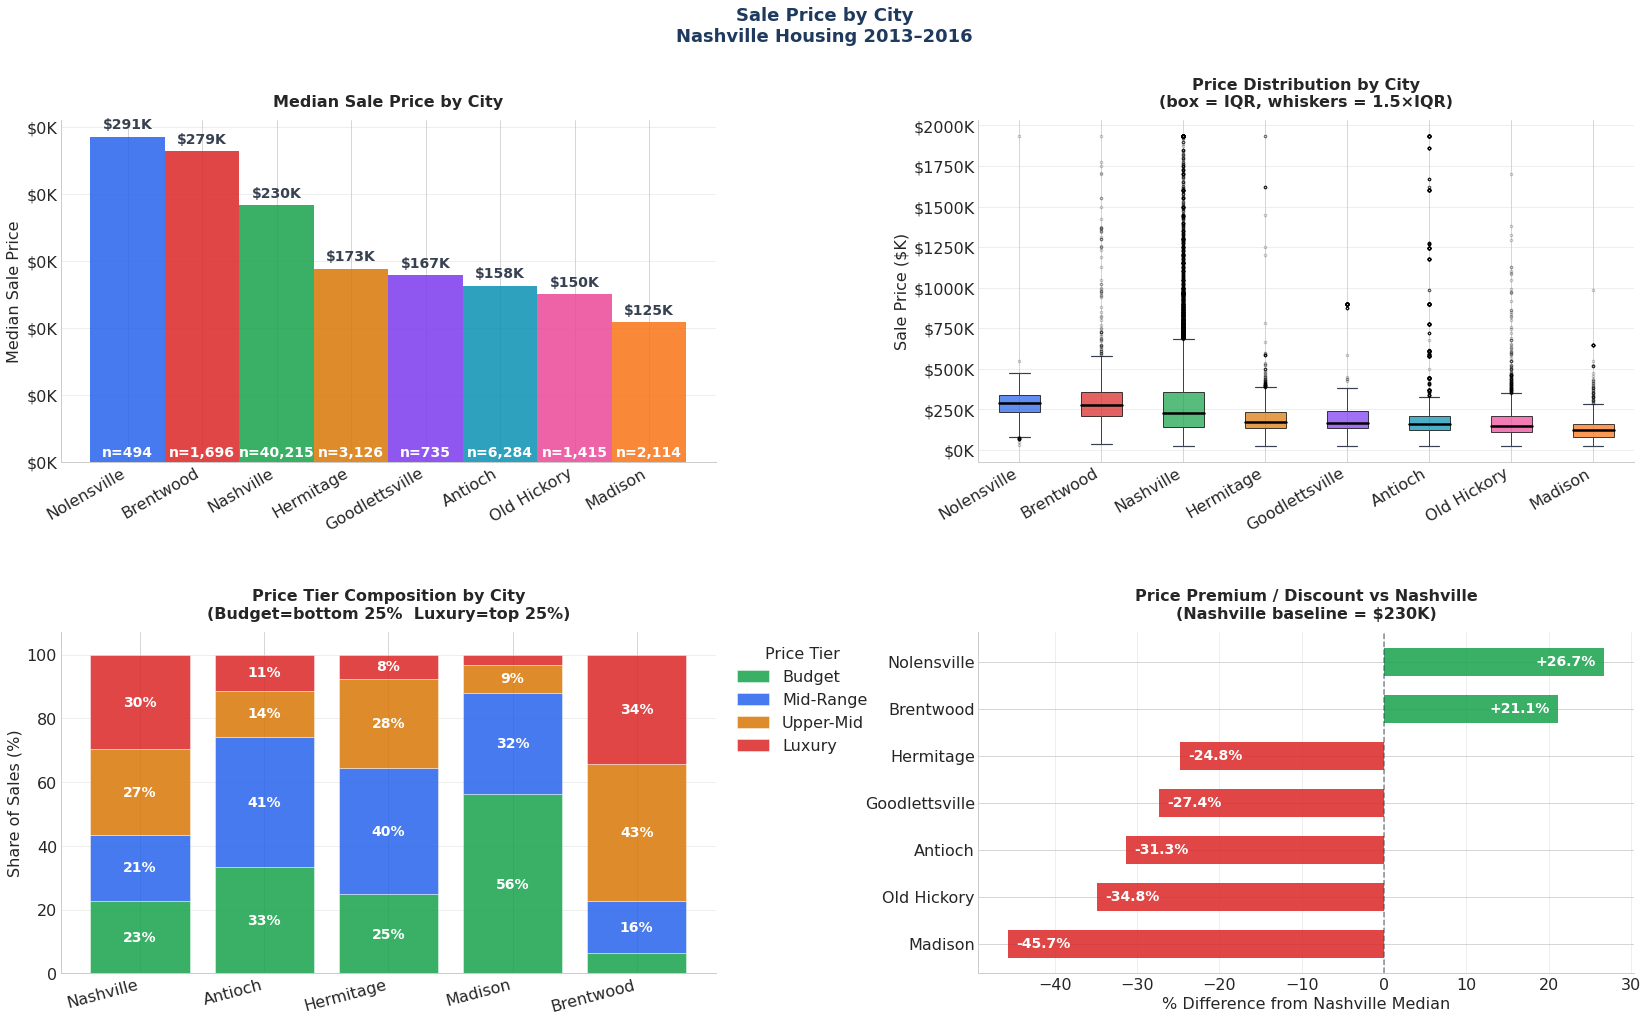

In [33]:
fig1, axes = plt.subplots(2, 2, figsize=(23, 14))
fig1.suptitle("Sale Price by City\nNashville Housing 2013–2016",
              fontsize=18, fontweight="bold", color="#1E3A5F", y=1.01)
 
# 1a: Median price bar chart top 8 cities
ax = axes[0, 0]
city_stats = (df_top8.groupby("Property City")["Sale Price"]
              .agg(["median", "count", "std"])
              .sort_values("median", ascending=False))

bars = ax.bar(range(len(city_stats)), city_stats["median"] / 1000,
              color=CITY_PAL[:len(city_stats)], alpha=0.85,
              edgecolor="none", width=1)

ax.set_xticks(range(len(city_stats)))
ax.set_xticklabels([c.title() for c in city_stats.index],
                   rotation=30, ha="right", fontsize=14)

ax.set_title("Median Sale Price by City", fontsize=16, fontweight="bold")
ax.set_ylabel("Median Sale Price", fontsize = 16)
ax.tick_params(labelsize=16)
kfmt(ax)
ax.grid(axis="y", alpha=0.4)
add_median_label(ax, bars, city_stats["median"])

# Sample size annotation
for i, (city, row) in enumerate(city_stats.iterrows()):
    ax.text(i, 5, f"n={int(row['count']):,}", ha="center",
            fontsize=14, color="white", fontweight="bold")

    

# 1b: Box plot: price spread by city
ax = axes[0, 1]
city_order = city_stats.index.tolist()          # sorted by median desc
data_box = [df_top8[df_top8["Property City"] == c]["Sale Price"].values / 1000
            for c in city_order]
bp = ax.boxplot(data_box, patch_artist=True, notch=False,
                medianprops=dict(color="black", linewidth=2.5),
                flierprops=dict(marker="o", markersize=2.5, alpha=0.25),
                whiskerprops=dict(color=GRAY, linewidth=1),
                capprops=dict(color=GRAY, linewidth=1.2))

for patch, color in zip(bp["boxes"], CITY_PAL):
    patch.set_facecolor(color); patch.set_alpha(0.72)
    
ax.set_xticklabels([c.title() for c in city_order],
                   rotation=30, ha="right", fontsize=16)

ax.set_title("Price Distribution by City\n(box = IQR, whiskers = 1.5×IQR)",
             fontsize=16, fontweight="bold")
ax.set_ylabel("Sale Price ($K)", fontsize = 16)
ax.tick_params(labelsize=16)
ax.grid(axis="y", alpha=0.4)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))


# 1c: Price tier mix by city: stacked bar %
ax = axes[1, 0]
ct = (df_top5.groupby(["Property City", "Price_Category"], observed=True)
      .size().unstack(fill_value=0).reindex(columns=TIER_ORDER))
ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
ct_pct = ct_pct.loc[TOP5_CITIES]             # keep city order consistent
 
bottom = np.zeros(len(ct_pct))
for tier, color in zip(TIER_ORDER, TIER_PAL):
    vals = ct_pct[tier].values
    bars = ax.bar(range(len(ct_pct)), vals, bottom=bottom,
                  color=color, alpha=0.85, label=tier,
                  edgecolor="white", linewidth=0.5)
    for i, (bar, val, bot) in enumerate(zip(bars, vals, bottom)):
        if val > 7:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bot + val / 2, f"{val:.0f}%",
                    ha="center", va="center",
                    fontsize=14, color="white", fontweight="bold")
    bottom += vals

ax.set_xticks(range(len(ct_pct)))
ax.set_xticklabels([c.title() for c in ct_pct.index],
                   rotation=15, ha="right", fontsize=9)
ax.set_title("Price Tier Composition by City\n"
             "(Budget=bottom 25%  Luxury=top 25%)",
             fontsize=16, fontweight="bold")

ax.set_ylabel("Share of Sales (%)", fontsize = 16)
ax.tick_params(labelsize=16)
ax.set_ylim(0, 107)

ax.legend(title="Price Tier", fontsize=16, title_fontsize=16,
          bbox_to_anchor=(1.01, 1), loc="upper left")

ax.grid(axis="y", alpha=0.4)


 
# 1d: Median price % premium vs Nashville baseline
ax = axes[1, 1]
nash_median = city_stats.loc["NASHVILLE", "median"]
premium_pct = ((city_stats["median"] - nash_median) / nash_median * 100).drop("NASHVILLE")
premium_pct = premium_pct.sort_values(ascending=True)
colors_prem = [GREEN if v >= 0 else CORAL for v in premium_pct.values]
bars = ax.barh(range(len(premium_pct)), premium_pct.values,
               color=colors_prem, alpha=0.85, edgecolor="none", height=0.6)

ax.axvline(0, color=GRAY, linewidth=1.5, linestyle="--", alpha=0.6)

ax.set_yticks(range(len(premium_pct)))
ax.set_yticklabels([c.title() for c in premium_pct.index], fontsize=16)
ax.set_title(f"Price Premium / Discount vs Nashville\n"
             f"(Nashville baseline = ${nash_median/1e3:.0f}K)",
             fontsize=16, fontweight="bold")

ax.set_xlabel("% Difference from Nashville Median", fontsize=16)
ax.tick_params(labelsize=16)
ax.grid(axis="x", alpha=0.4)


for bar, val in zip(bars, premium_pct.values):
    # If positive, align right so it's inside the right edge. If negative, align left.
    x_pos = val - 1.0 if val >= 0 else val + 1.0
    alignment = "right" if val >= 0 else "left"
    
    ax.text(x_pos,
            bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}%", va="center",
            ha=alignment,
            fontsize=14, color="white", fontweight="bold")
    
plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()

#### (2) Land Use 

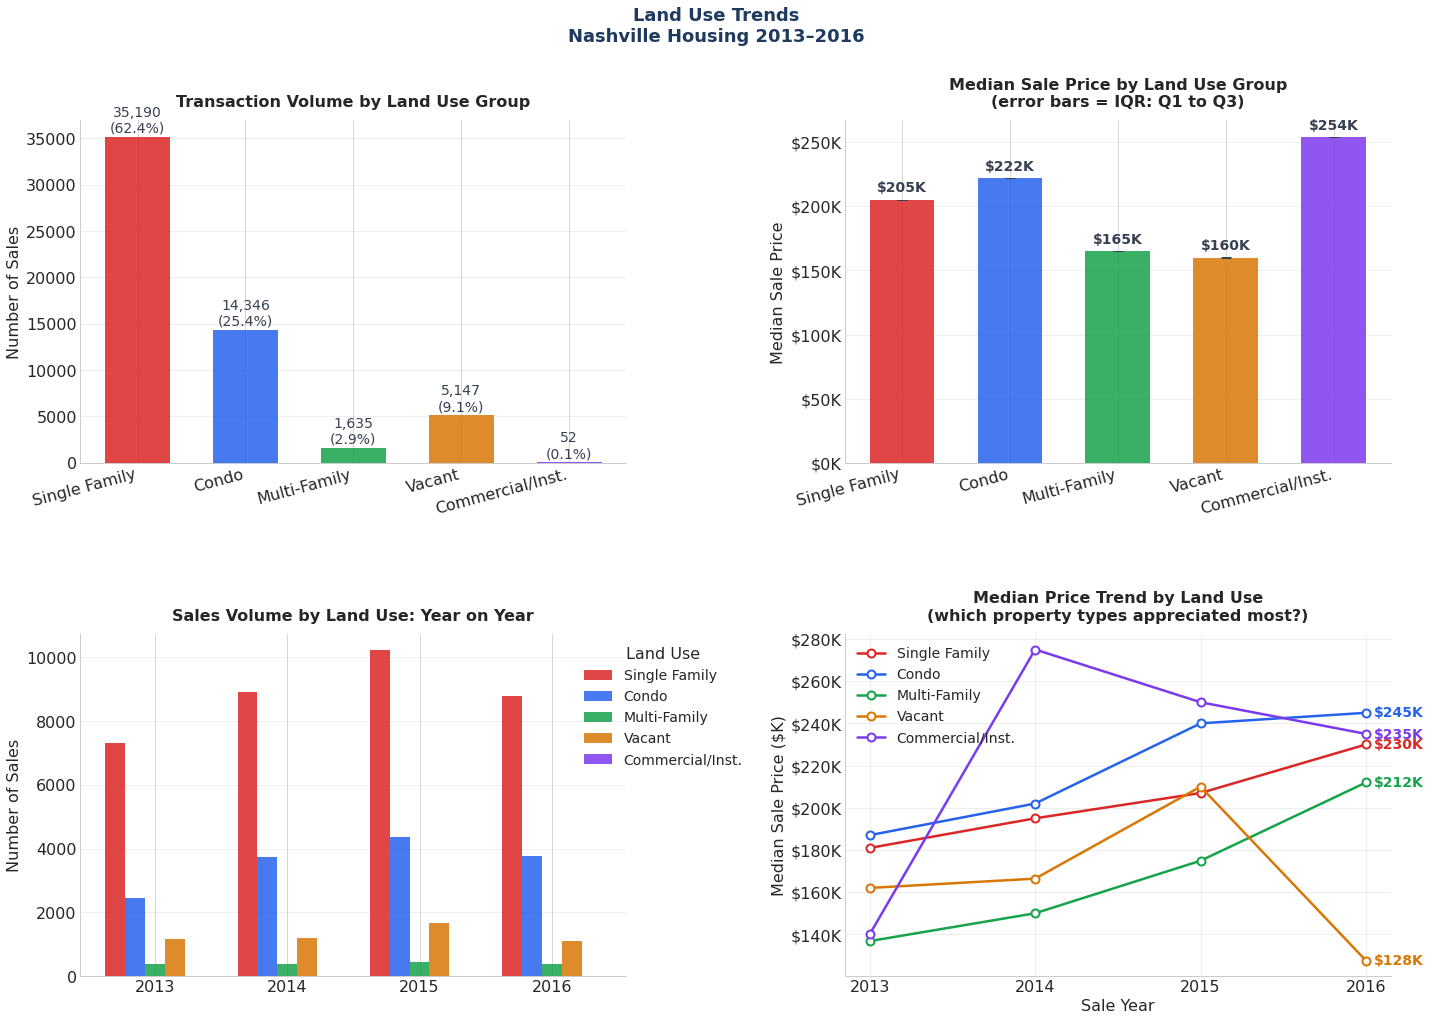

In [34]:
fig2, axes = plt.subplots(2, 2, figsize=(20, 14))
fig2.suptitle("Land Use Trends\nNashville Housing 2013–2016",
              fontsize=18, fontweight="bold", color="#1E3A5F", y=1.01)
 
# 2a: Volume by land use group
ax = axes[0, 0]
lu_vol = df["Land_Use_Group"].value_counts().reindex(LU_ORDER)
bars = ax.bar(range(len(lu_vol)), lu_vol.values,
              color=LU_PAL, alpha=0.85, edgecolor="none", width=0.6)
ax.set_xticks(range(len(lu_vol)))
ax.set_xticklabels(LU_ORDER, rotation=15, ha="right", fontsize=16)
ax.set_title("Transaction Volume by Land Use Group",
             fontsize=16, fontweight="bold")
ax.set_ylabel("Number of Sales", fontsize = 16)
ax.tick_params(labelsize=16)
ax.grid(axis="y", alpha=0.4)

for bar, val in zip(bars, lu_vol.values):
    pct = val / len(df) * 100
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + len(df) * 0.003,
            f"{val:,}\n({pct:.1f}%)",
            ha="center", va="bottom", fontsize=14, color=GRAY)

    
# 2b: Median price by land use with IQR error bars
ax = axes[0, 1]
lu_price = df.groupby("Land_Use_Group")["Sale Price"].agg(
    median="median",
    q25=lambda x: x.quantile(0.25),
    q75=lambda x: x.quantile(0.75)
).reindex(LU_ORDER)

yerr_lo = (lu_price["median"] - lu_price["q25"]).values / 1000
yerr_hi = (lu_price["q75"] - lu_price["median"]).values / 1000
bars = ax.bar(range(len(lu_price)), lu_price["median"] ,
              color=LU_PAL, alpha=0.85, edgecolor="none", width=0.6,
              yerr=[yerr_lo, yerr_hi],
              error_kw=dict(ecolor=GRAY, capsize=5, linewidth=1.5))

ax.set_xticks(range(len(lu_price)))
ax.set_xticklabels(LU_ORDER, rotation=15, ha="right", fontsize=16)
ax.set_title("Median Sale Price by Land Use Group\n"
             "(error bars = IQR: Q1 to Q3)",
             fontsize=16, fontweight="bold")
ax.tick_params(labelsize=16)
ax.set_ylabel("Median Sale Price", fontsize = 16)
kfmt(ax)
ax.grid(axis="y", alpha=0.4)
add_median_label(ax, bars, lu_price["median"])



# 2c: Land use volume trend by year grouped bar
ax = axes[1, 0]
YEARS = sorted(df["Sale_Year"].unique())
lu_yr = (df.groupby(["Sale_Year", "Land_Use_Group"])
          .size().unstack(fill_value=0).reindex(columns=LU_ORDER))
n_lu  = len(LU_ORDER)
x     = np.arange(len(YEARS))
width = 0.15
for i, (lu, color) in enumerate(zip(LU_ORDER, LU_PAL)):
    offset = (i - n_lu / 2 + 0.5) * width
    bars   = ax.bar(x + offset, lu_yr[lu].values,
                    width=width, color=color, alpha=0.85,
                    edgecolor="none", label=lu)
ax.set_xticks(x)
ax.set_xticklabels(YEARS, fontsize=16)
ax.set_title("Sales Volume by Land Use: Year on Year",
             fontsize=16, fontweight="bold")
ax.set_ylabel("Number of Sales", fontsize = 16)
ax.tick_params(labelsize=16)
ax.legend(title="Land Use", fontsize=14, title_fontsize=16,
          bbox_to_anchor=(0.9, 1), loc="upper left")
ax.grid(axis="y", alpha=0.4)



# 2d: Median price by land use over years line chart
ax = axes[1, 1]
for lu, color in zip(LU_ORDER, LU_PAL):   
    lu_trend = (df[df["Land_Use_Group"] == lu]
                .groupby("Sale_Year")["Sale Price"].median() / 1000)
    ax.plot(lu_trend.index, lu_trend.values, color=color, linewidth=2.5,
            marker="o", markersize=8, label=lu,
            markerfacecolor="white", markeredgewidth=2)
    
    # Annotate end point
    ax.annotate(f"${lu_trend.iloc[-1]:.0f}K",
                xy=(lu_trend.index[-1], lu_trend.iloc[-1]),
                xytext=(8, 0), textcoords="offset points",
                fontsize=14, color=color, fontweight="bold", va="center")

ax.set_title("Median Price Trend by Land Use\n"
             "(which property types appreciated most?)",
             fontsize=16, fontweight="bold")
ax.set_xlabel("Sale Year", fontsize = 16)
ax.set_ylabel("Median Sale Price ($K)", fontsize = 16)
ax.tick_params(labelsize=16)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
ax.set_xticks(YEARS)
ax.legend(fontsize=14)
ax.grid(alpha=0.4)
 
plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.4)

plt.show()

#### (3) Sale Year Trends

C:\Users\hp\AppData\Local\Temp\ipykernel_20936\2191330539.py:67: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(im, ax=ax, label="Median Sale Price ($K)", shrink=0.85)


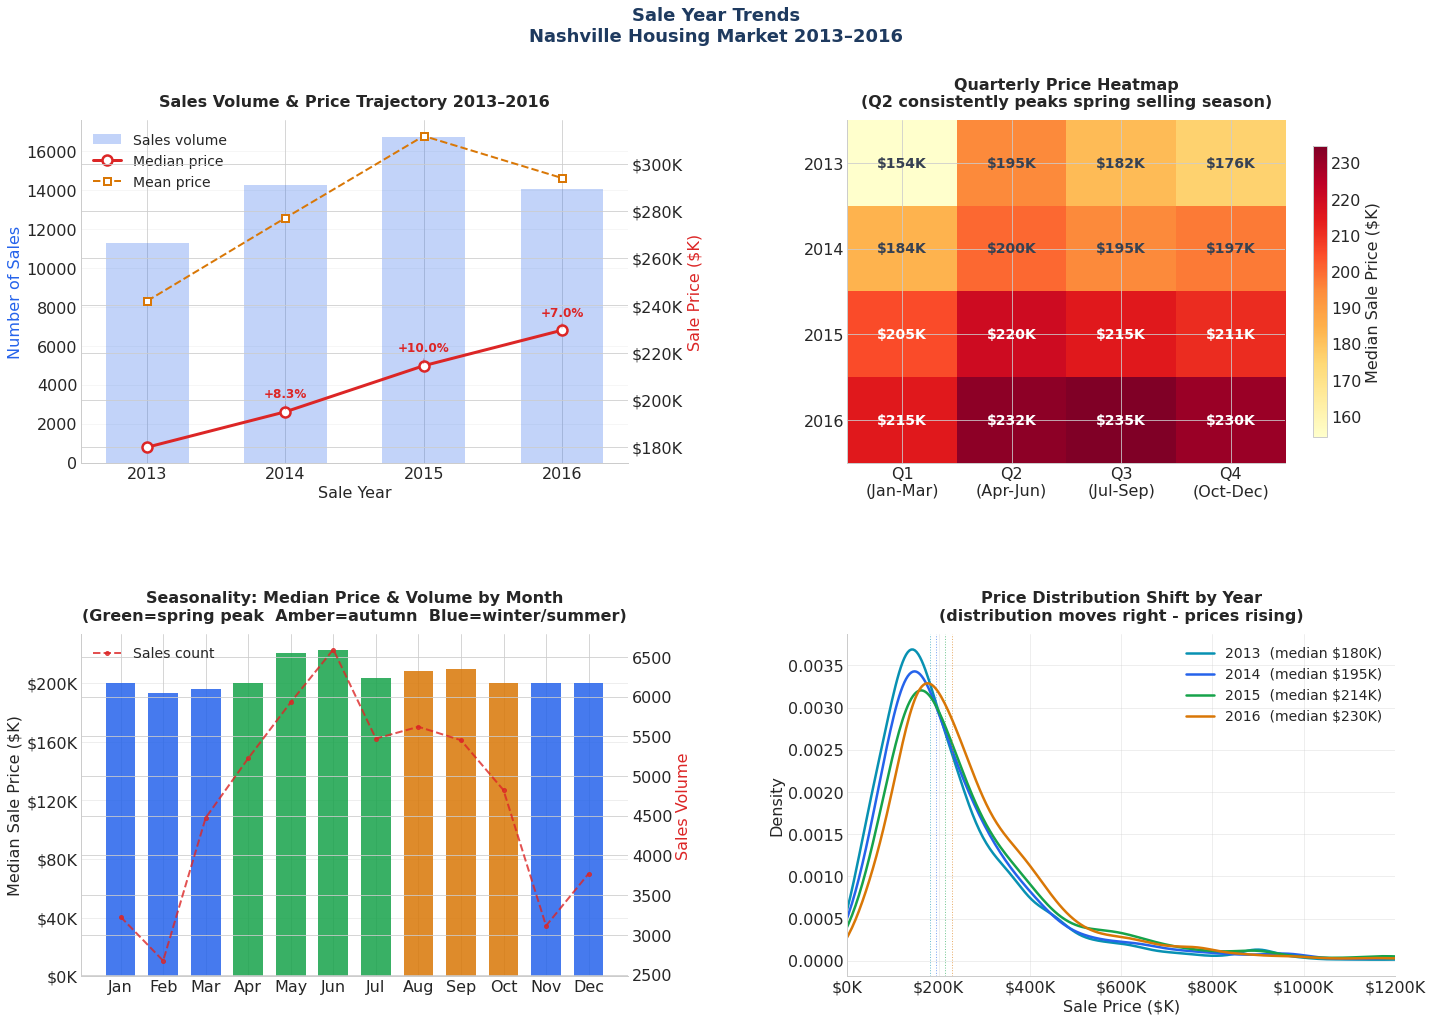

In [35]:
fig3, axes = plt.subplots(2, 2, figsize=(20, 14))
fig3.suptitle("Sale Year Trends\nNashville Housing Market 2013–2016",
              fontsize=18, fontweight="bold", color="#1E3A5F", y=1.01)
 
# 3a: Dual-axis volume (bars) + median price (line)
ax = axes[0, 0]
yearly = df.groupby("Sale_Year")["Sale Price"].agg(
    ["median", "mean", "count", "std"]).reset_index()
ax2 = ax.twinx()
 
ax.bar(yearly["Sale_Year"], yearly["count"],
       color=BLUE, alpha=0.28, width=0.6, label="Sales volume")

ax2.plot(yearly["Sale_Year"], yearly["median"] / 1000,
         color=CORAL, linewidth=3, marker="o",
         markersize=10, markerfacecolor="white",
         markeredgewidth=2.5, label="Median price")

ax2.plot(yearly["Sale_Year"], yearly["mean"] / 1000,
         color=AMBER, linewidth=2, marker="s", markersize=7,
         markerfacecolor="white", markeredgewidth=2,
         linestyle="--", label="Mean price")
 
# YoY pct annotations on median line
for i in range(1, len(yearly)):
    pct = ((yearly["median"].iloc[i] - yearly["median"].iloc[i-1])
           / yearly["median"].iloc[i-1] * 100)
    ax2.annotate(f"{pct:+.1f}%",
                 xy=(yearly["Sale_Year"].iloc[i],
                     yearly["median"].iloc[i] / 1000),
                 xytext=(0, 14), textcoords="offset points",
                 ha="center", fontsize=12, color=CORAL, fontweight="bold",
                 arrowprops=dict(arrowstyle="-", color=CORAL,
                                 lw=0.8, alpha=0.5))

    
ax.set_xlabel("Sale Year", fontsize = 16)
ax.set_ylabel("Number of Sales", color=BLUE, fontsize = 16)
ax2.set_ylabel("Sale Price ($K)", color=CORAL, fontsize = 16)
ax2.tick_params(labelsize=16)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))

ax.set_title("Sales Volume & Price Trajectory 2013–2016",
             fontsize=16, fontweight="bold")

l1, lb1 = ax.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax.legend(l1 + l2, lb1 + lb2, fontsize=14, loc="upper left")
ax.set_xticks(YEARS)
ax.tick_params(labelsize=16)
ax.grid(axis="y", alpha=0.2)
 
    
    
# 3b: Quarterly seasonality heatmap style
ax = axes[0, 1]
q_pivot = (df.groupby(["Sale_Year", "Sale_Quarter"])["Sale Price"]
           .median().unstack() / 1000)
im = ax.imshow(q_pivot.values, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(4))
ax.set_xticklabels(["Q1\n(Jan-Mar)", "Q2\n(Apr-Jun)",
                    "Q3\n(Jul-Sep)", "Q4\n(Oct-Dec)"], fontsize=16)
ax.set_yticks(range(len(YEARS)))
ax.set_yticklabels(YEARS, fontsize=16)
ax.tick_params(labelsize=16)

cbar = plt.colorbar(im, ax=ax, label="Median Sale Price ($K)", shrink=0.85)
cbar.set_label("Median Sale Price ($K)", fontsize=16) 
cbar.ax.tick_params(labelsize=16)

# Annotate cells
for i in range(len(YEARS)):
    for j in range(4):
        val = q_pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"${val:.0f}K", ha="center", va="center",
                    fontsize=14, fontweight="bold",
                    color="white" if val > q_pivot.values.mean() else GRAY)
            
ax.set_title("Quarterly Price Heatmap\n"
             "(Q2 consistently peaks spring selling season)",
             fontsize=16, fontweight="bold")



# 3c: Monthly seasonality average across all years
ax = axes[1, 0]
MONTH_LABELS = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]
monthly = df.groupby("Sale_Month")["Sale Price"].agg(["median","count"])
bar_colors = [GREEN if m in [4,5,6,7] else
              (AMBER if m in [8,9,10] else BLUE)
              for m in monthly.index]

bars = ax.bar(monthly.index, monthly["median"],
              color=bar_colors, alpha=0.85, edgecolor="none", width=0.7)
ax2_m = ax.twinx()
ax2_m.plot(monthly.index, monthly["count"], color=CORAL,
           linewidth=2, marker=".", markersize=8,
           linestyle="--", label="Sales count", alpha=0.8)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_LABELS, fontsize=9)
ax.set_title("Seasonality: Median Price & Volume by Month\n"
             "(Green=spring peak  Amber=autumn  Blue=winter/summer)",
             fontsize=16, fontweight="bold")
ax.tick_params(labelsize=16)
ax.set_ylabel("Median Sale Price ($K)", fontsize = 16)
kfmt(ax)

ax2_m.set_ylabel("Sales Volume", color=CORAL, fontsize = 16)
ax2_m.tick_params(labelsize=16)
ax2_m.legend(fontsize=14, loc="upper left")

ax.grid(axis="y", alpha=0.4)


 
# 3d: Price distribution shift KDE by year
ax = axes[1, 1]
for year, color in zip(YEARS, YEAR_PAL):
    s = df[df["Sale_Year"] == year]["Sale Price"] / 1000
    s.plot.kde(ax=ax, color=color, linewidth=2.5,
               label=f"{year}  (median ${s.median():.0f}K)")
    ax.axvline(s.median(), color=color, linewidth=1,
               linestyle=":", alpha=0.6)
    
ax.set_title("Price Distribution Shift by Year\n"
             "(distribution moves right - prices rising)",
             fontsize=16, fontweight="bold")

ax.set_xlabel("Sale Price ($K)", fontsize = 16)
ax.set_ylabel("Density", fontsize = 16)
ax.tick_params(labelsize=16)
ax.set_xlim(0, 1200)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
ax.legend(fontsize=14)
ax.grid(alpha=0.4)
 
plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()

#### (4) Price Category

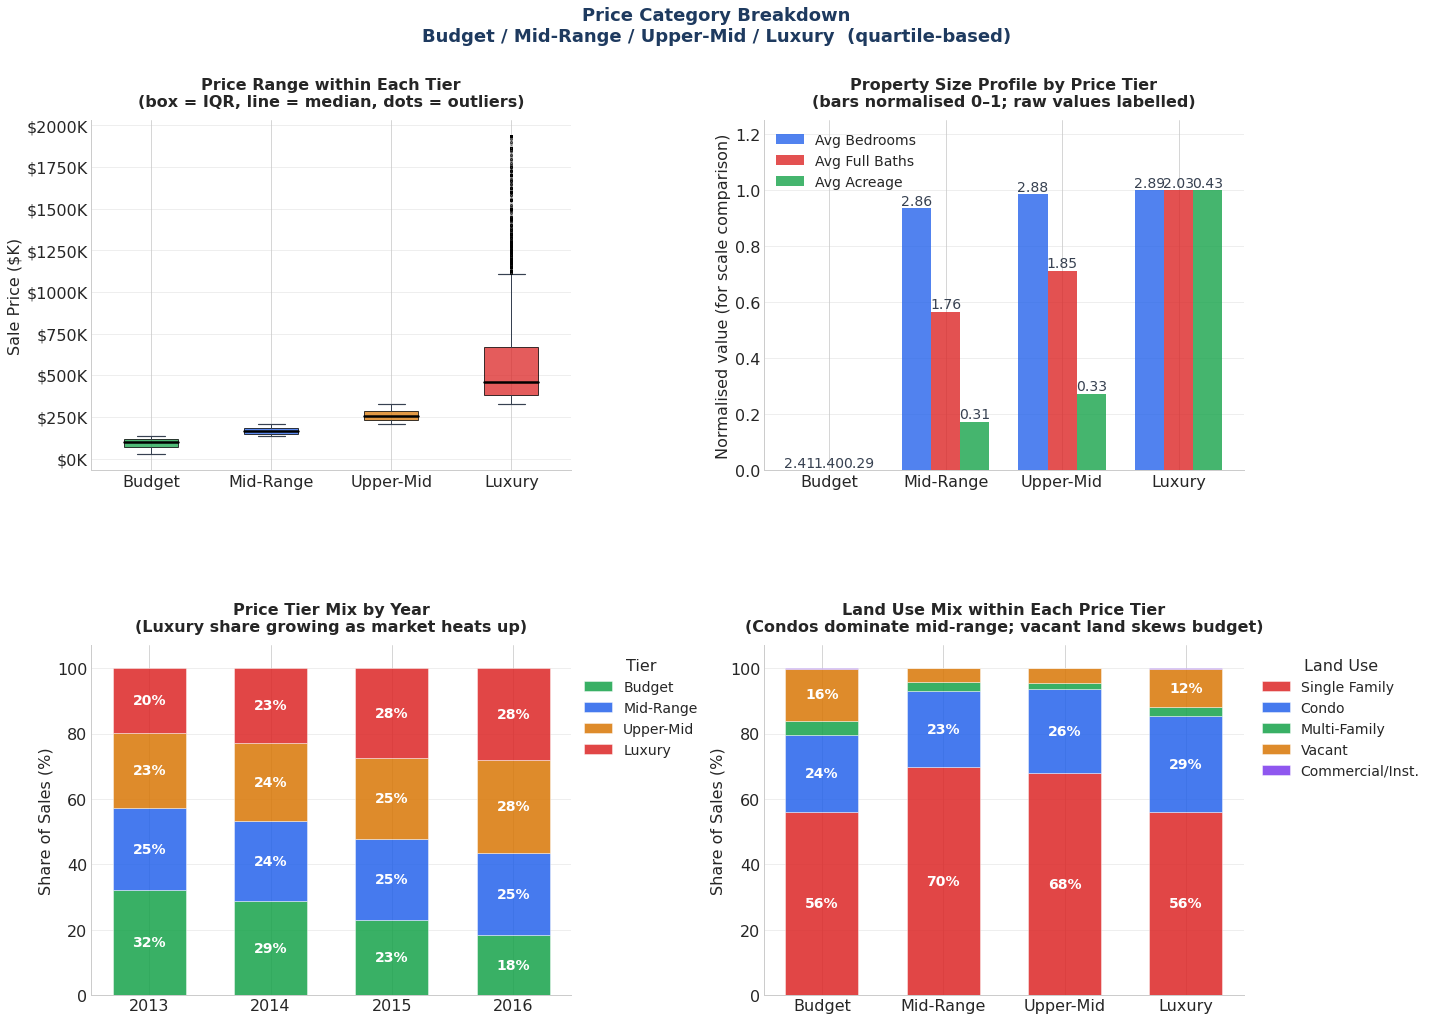

In [36]:
fig4, axes = plt.subplots(2, 2, figsize=(20, 14))
fig4.suptitle("Price Category Breakdown\n"
              "Budget / Mid-Range / Upper-Mid / Luxury  (quartile-based)",
              fontsize=18, fontweight="bold", color="#1E3A5F", y=1.01)
 
# 4a: Price range per tier box
ax = axes[0, 0]
data_tier = [df[df["Price_Category"] == t]["Sale Price"].values / 1000
             for t in TIER_ORDER]
bp = ax.boxplot(data_tier, patch_artist=True, notch=False,
                medianprops=dict(color="black", linewidth=2.5),
                flierprops=dict(marker="o", markersize=2, alpha=0.25),
                whiskerprops=dict(color=GRAY, linewidth=1),
                capprops=dict(color=GRAY, linewidth=1.2))

for patch, color in zip(bp["boxes"], TIER_PAL):
    patch.set_facecolor(color); patch.set_alpha(0.75)
    
ax.set_xticklabels(TIER_ORDER, fontsize=16)
ax.set_title("Price Range within Each Tier\n"
             "(box = IQR, line = median, dots = outliers)",
             fontsize=16, fontweight="bold")

ax.set_ylabel("Sale Price ($K)", fontsize = 16)
ax.tick_params(labelsize=16) 
ax.grid(axis="y", alpha=0.4)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))

# Annotate thresholds
for tier, color in zip(TIER_ORDER, TIER_PAL):
    med = df[df["Price_Category"] == tier]["Sale Price"].median()
    q75 = df[df["Price_Category"] == tier]["Sale Price"].quantile(0.75)


    
# 4b: Property characteristics by tier: radar-style bar
ax = axes[0, 1]
res_tier = df.dropna(subset=["Price_Category"])
tier_profile = res_tier.groupby("Price_Category", observed=True).agg(
    Bedrooms=("Bedrooms", "mean"),
    Full_Bath=("Full Bath", "mean"),
    Acreage=("Acreage", "mean"),
).reindex(TIER_ORDER)
 
x = np.arange(len(TIER_ORDER))
metrics_bar = ["Bedrooms", "Full_Bath", "Acreage"]
metric_labels = ["Avg Bedrooms", "Avg Full Baths", "Avg Acreage"]
width = 0.25
metric_colors = [BLUE, CORAL, GREEN]
 
for i, (metric, label, color) in enumerate(
        zip(metrics_bar, metric_labels, metric_colors)):
    vals = tier_profile[metric].values
    
    # Normalise to 0-1 so all metrics fit on one chart
    norm = (vals - vals.min()) / (vals.max() - vals.min() + 1e-9)
    bars = ax.bar(x + (i - 1) * width, norm, width=width,
                  color=color, alpha=0.8, label=label, edgecolor="none")
    for bar, raw in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.012,
                f"{raw:.2f}", ha="center", fontsize=14, color=GRAY)

ax.set_xticks(x)
ax.set_xticklabels(TIER_ORDER, fontsize=16)
ax.set_title("Property Size Profile by Price Tier\n"
             "(bars normalised 0–1; raw values labelled)",
             fontsize=16, fontweight="bold")
ax.set_ylabel("Normalised value (for scale comparison)", fontsize= 16)
ax.tick_params(labelsize=16) 
ax.legend(fontsize=14)
ax.grid(axis="y", alpha=0.4)
ax.set_ylim(0, 1.25)




# 4c: Tier volume by year: stacked bar
ax = axes[1, 0]
tier_yr = (df.groupby(["Sale_Year", "Price_Category"], observed=True)
           .size().unstack(fill_value=0).reindex(columns=TIER_ORDER))
tier_yr_pct = tier_yr.div(tier_yr.sum(axis=1), axis=0) * 100
 
bottom = np.zeros(len(YEARS))
for tier, color in zip(TIER_ORDER, TIER_PAL):
    vals = tier_yr_pct[tier].values
    bars = ax.bar(YEARS, vals, bottom=bottom, color=color,
                  alpha=0.85, label=tier,
                  edgecolor="white", linewidth=0.5, width=0.6)
    for bar, val, bot, yr in zip(bars, vals, bottom, YEARS):
        if val > 6:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bot + val / 2, f"{val:.0f}%",
                    ha="center", va="center",
                    fontsize=14, color="white", fontweight="bold")
    bottom += vals

    
ax.set_title("Price Tier Mix by Year\n"
             "(Luxury share growing as market heats up)",
             fontsize=16, fontweight="bold")
ax.set_ylabel("Share of Sales (%)", fontsize = 16)
ax.tick_params(labelsize=16) 
ax.set_ylim(0, 107)
ax.set_xticks(YEARS)
ax.legend(title="Tier", fontsize=14, title_fontsize=16,
          bbox_to_anchor=(1, 1), loc="upper left")
ax.grid(axis="y", alpha=0.4)



# 4d: Land use mix within each tier
ax = axes[1, 1]
lu_tier = (df.groupby(["Price_Category", "Land_Use_Group"], observed=True)
           .size().unstack(fill_value=0).reindex(columns=LU_ORDER))
lu_tier_pct = lu_tier.div(lu_tier.sum(axis=1), axis=0) * 100
 
bottom = np.zeros(len(TIER_ORDER))
for lu, color in zip(LU_ORDER, LU_PAL):
    vals = lu_tier_pct.reindex(TIER_ORDER)[lu].values
    bars = ax.bar(TIER_ORDER, vals, bottom=bottom, color=color,
                  alpha=0.85, label=lu,
                  edgecolor="white", linewidth=0.5, width=0.6)
    for bar, val, bot in zip(bars, vals, bottom):
        if val > 7:
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bot + val / 2, f"{val:.0f}%",
                    ha="center", va="center",
                    fontsize=14, color="white", fontweight="bold")
    bottom += vals

ax.set_title("Land Use Mix within Each Price Tier\n"
             "(Condos dominate mid-range; vacant land skews budget)",
             fontsize=16, fontweight="bold")
ax.set_ylabel("Share of Sales (%)", fontsize = 16)
ax.tick_params(labelsize=16) 
ax.set_ylim(0, 107)

ax.legend(title="Land Use", fontsize=14, title_fontsize=16,
          bbox_to_anchor=(1.01, 1), loc="upper left")
ax.grid(axis="y", alpha=0.4)


plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()

#### (5) city × land use × year × tier

C:\Users\hp\AppData\Local\Temp\ipykernel_20936\1614969068.py:21: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(im, ax=ax, label="Median Sale Price ($K)", shrink=0.85)
C:\Users\hp\AppData\Local\Temp\ipykernel_20936\1614969068.py:51: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  cbar = plt.colorbar(im2, ax=ax, label="Median Sale Price ($K)", shrink=0.85)


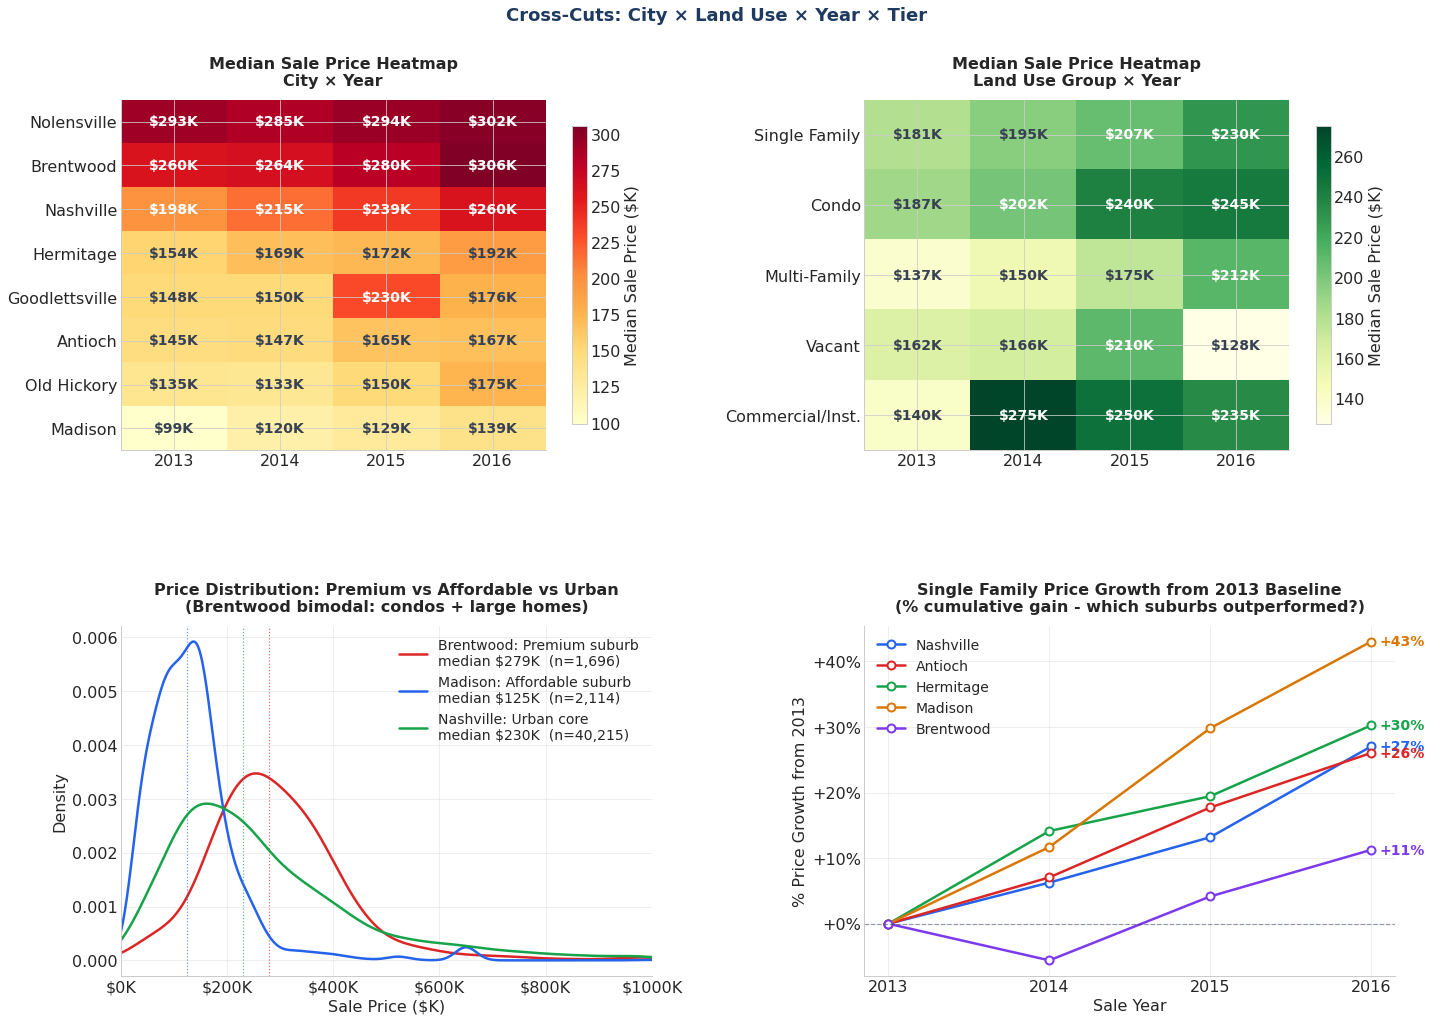

In [37]:
fig5, axes = plt.subplots(2, 2, figsize=(20, 14))
fig5.suptitle("Cross-Cuts: City × Land Use × Year × Tier",
              fontsize=18, fontweight="bold", color="#1E3A5F", y=1.01)
 
# 5a: Heatmap: median price by city × year
ax = axes[0, 0]
city_yr = (df_top8.groupby(["Property City", "Sale_Year"])["Sale Price"]
           .median().unstack() / 1000)

city_yr = city_yr.reindex(
    city_yr.median(axis=1).sort_values(ascending=False).index)
im = ax.imshow(city_yr.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(YEARS)))
ax.set_xticklabels(YEARS, fontsize=16)
ax.set_yticks(range(len(city_yr.index)))
ax.tick_params(labelsize=16)

ax.set_yticklabels([c.title() for c in city_yr.index], fontsize=16)

cbar = plt.colorbar(im, ax=ax, label="Median Sale Price ($K)", shrink=0.85)
cbar.set_label("Median Sale Price ($K)", fontsize=16) 
cbar.ax.tick_params(labelsize=16)

for i in range(len(city_yr.index)):
    for j, yr in enumerate(YEARS):
        val = city_yr.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"${val:.0f}K", ha="center", va="center",
                    fontsize=14, fontweight="bold",
                    color="white" if val > city_yr.values.mean() else GRAY)
            
ax.set_title("Median Sale Price Heatmap\nCity × Year",
             fontsize=16, fontweight="bold")



# 5b: Heatmap: median price by land use × year
ax = axes[0, 1]
lu_yr_price = (df.groupby(["Land_Use_Group", "Sale_Year"])["Sale Price"]
               .median().unstack() / 1000).reindex(LU_ORDER)

im2 = ax.imshow(lu_yr_price.values, cmap="YlGn", aspect="auto")

ax.set_xticks(range(len(YEARS)))
ax.set_xticklabels(YEARS, fontsize=16)
ax.set_yticks(range(len(LU_ORDER)))
ax.set_yticklabels(LU_ORDER, fontsize=16)
ax.tick_params(labelsize=16)

cbar = plt.colorbar(im2, ax=ax, label="Median Sale Price ($K)", shrink=0.85)
cbar.set_label("Median Sale Price ($K)", fontsize=16) 
cbar.ax.tick_params(labelsize=16)

for i in range(len(LU_ORDER)):
    for j in range(len(YEARS)):
        val = lu_yr_price.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f"${val:.0f}K", ha="center", va="center",
                    fontsize=14, fontweight="bold",
                    color="white" if val > lu_yr_price.values.mean() else GRAY)
            
ax.set_title("Median Sale Price Heatmap\nLand Use Group × Year",
             fontsize=16, fontweight="bold")



# 5c: Brentwood vs Madison deep-dive: price distribution
ax = axes[1, 0]
pairs = [("BRENTWOOD", CORAL, "Premium suburb"),
         ("MADISON",   BLUE,  "Affordable suburb"),
         ("NASHVILLE", GREEN, "Urban core")]
for city, color, label in pairs:
    s = df[df["Property City"] == city]["Sale Price"] / 1000
    s.plot.kde(ax=ax, color=color, linewidth=2.5,
               label=f"{city.title()}: {label}\nmedian ${s.median():.0f}K  (n={len(s):,})")
    ax.axvline(s.median(), color=color, linewidth=1.2,
               linestyle=":", alpha=0.7)
    
ax.set_title("Price Distribution: Premium vs Affordable vs Urban\n"
             "(Brentwood bimodal: condos + large homes)",
             fontsize=16, fontweight="bold")
ax.set_xlabel("Sale Price ($K)", fontsize = 16)
ax.set_ylabel("Density", fontsize = 16)
ax.tick_params(labelsize=16)

ax.set_xlim(0, 1000)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
ax.legend(fontsize=14)
ax.grid(alpha=0.4)




# 5d: Single Family price by city over years: growth race
ax = axes[1, 1]
sf_city_yr = (df[(df["Land_Use_Group"] == "Single Family") &
                  (df["Property City"].isin(TOP5_CITIES))]
              .groupby(["Property City", "Sale_Year"])["Sale Price"]
              .median() / 1000).unstack().T
 
base_yr = sf_city_yr.loc[2013]
growth  = sf_city_yr.div(base_yr) * 100 - 100   # % growth from 2013 baseline
 
for city, color in zip(TOP5_CITIES, CITY_PAL):
    if city in growth.columns:
        ax.plot(growth.index, growth[city],
                color=color, linewidth=2.5, marker="o",
                markersize=8, markerfacecolor="white",
                markeredgewidth=2, label=city.title())
        ax.annotate(f"{growth[city].iloc[-1]:+.0f}%",
                    xy=(growth.index[-1], growth[city].iloc[-1]),
                    xytext=(8, 0), textcoords="offset points",
                    fontsize=14, color=color, fontweight="bold", va="center")

        
ax.axhline(0, color=GRAY, linewidth=1.2, linestyle="--", alpha=0.5)
ax.set_title("Single Family Price Growth from 2013 Baseline\n"
             "(% cumulative gain - which suburbs outperformed?)",
             fontsize=16, fontweight="bold")
ax.set_xlabel("Sale Year", fontsize = 16)
ax.set_ylabel("% Price Growth from 2013", fontsize = 16)
ax.set_xticks(YEARS)
ax.tick_params(labelsize=16)

ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+.0f}%"))
ax.legend(fontsize=14)
ax.grid(alpha=0.4)


plt.tight_layout()
plt.subplots_adjust(hspace=0.5, wspace=0.4)
plt.show()